<a href="https://colab.research.google.com/github/Pranayshukla0610/MLFlow/blob/main/Advanced_Regression_Pipeline_for_Airbnb_Price_Estimation_with_Feature_Engineering_and_Assumption_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile
import os
import hashlib

In [6]:
class DataIngestion:
  def __init__(self,zip_path,extract_path):
    self.zip_path = zip_path
    self.extract_path = extract_path

  def verify(self):
    with open(self.zip_path,'rb') as f:
      print('MD5:',hashlib.md5(f.read()).hexdigest())

  def extract(self):
    with zipfile.ZipFile(self.zip_path,'r') as zip_ref:
      zip_ref.extractall(self.extract_path)

  def list_files(self):
    return os.listdir(self.extract_path)

In [7]:
ingestion = DataIngestion('/content/archive (35).zip','/content/')
ingestion.verify()
ingestion.extract()
print(ingestion.list_files())

MD5: 129b1e9c6a2516ea06f4cb591e8deca2
['.config', 'AB_NYC_2019.csv', 'archive (35).zip', 'New_York_City_.png', 'sample_data']


In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv('/content/AB_NYC_2019.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [12]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [13]:
df.shape

(48895, 16)

In [14]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing": missing,
    "Percentage": missing_pct
})

In [15]:
print(missing_df.head())

                     Missing  Percentage
last_review            10052   20.558339
reviews_per_month      10052   20.558339
host_name                 21    0.042949
name                      16    0.032723
neighbourhood_group        0    0.000000


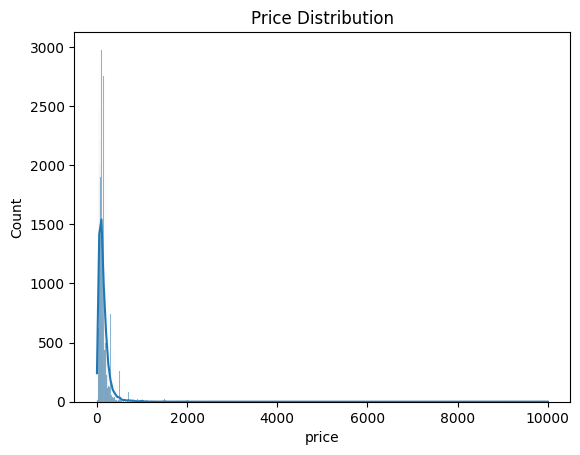

In [16]:
sns.histplot(df['price'],kde=True)
plt.title('Price Distribution')
plt.show()

In [18]:
print("Skewness:", df['price'].skew())

Skewness: 19.118938995046033


In [21]:
df = df[df['price'] > 0]

df['log_price'] = np.log1p(df['price'])

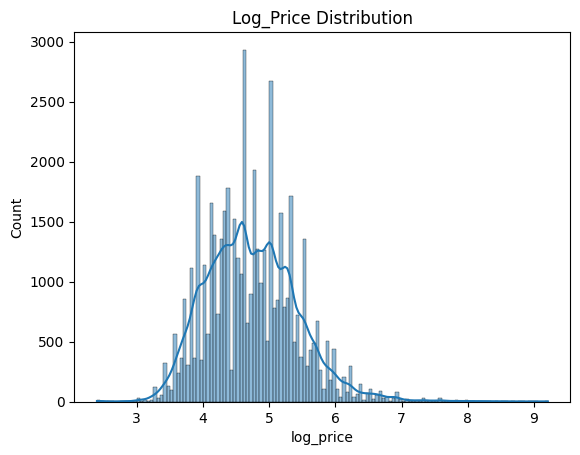

In [22]:
sns.histplot(df['log_price'],kde=True)
plt.title('Log_Price Distribution')
plt.show()

In [23]:
df['log_price'].skew()

np.float64(0.6294448333542216)

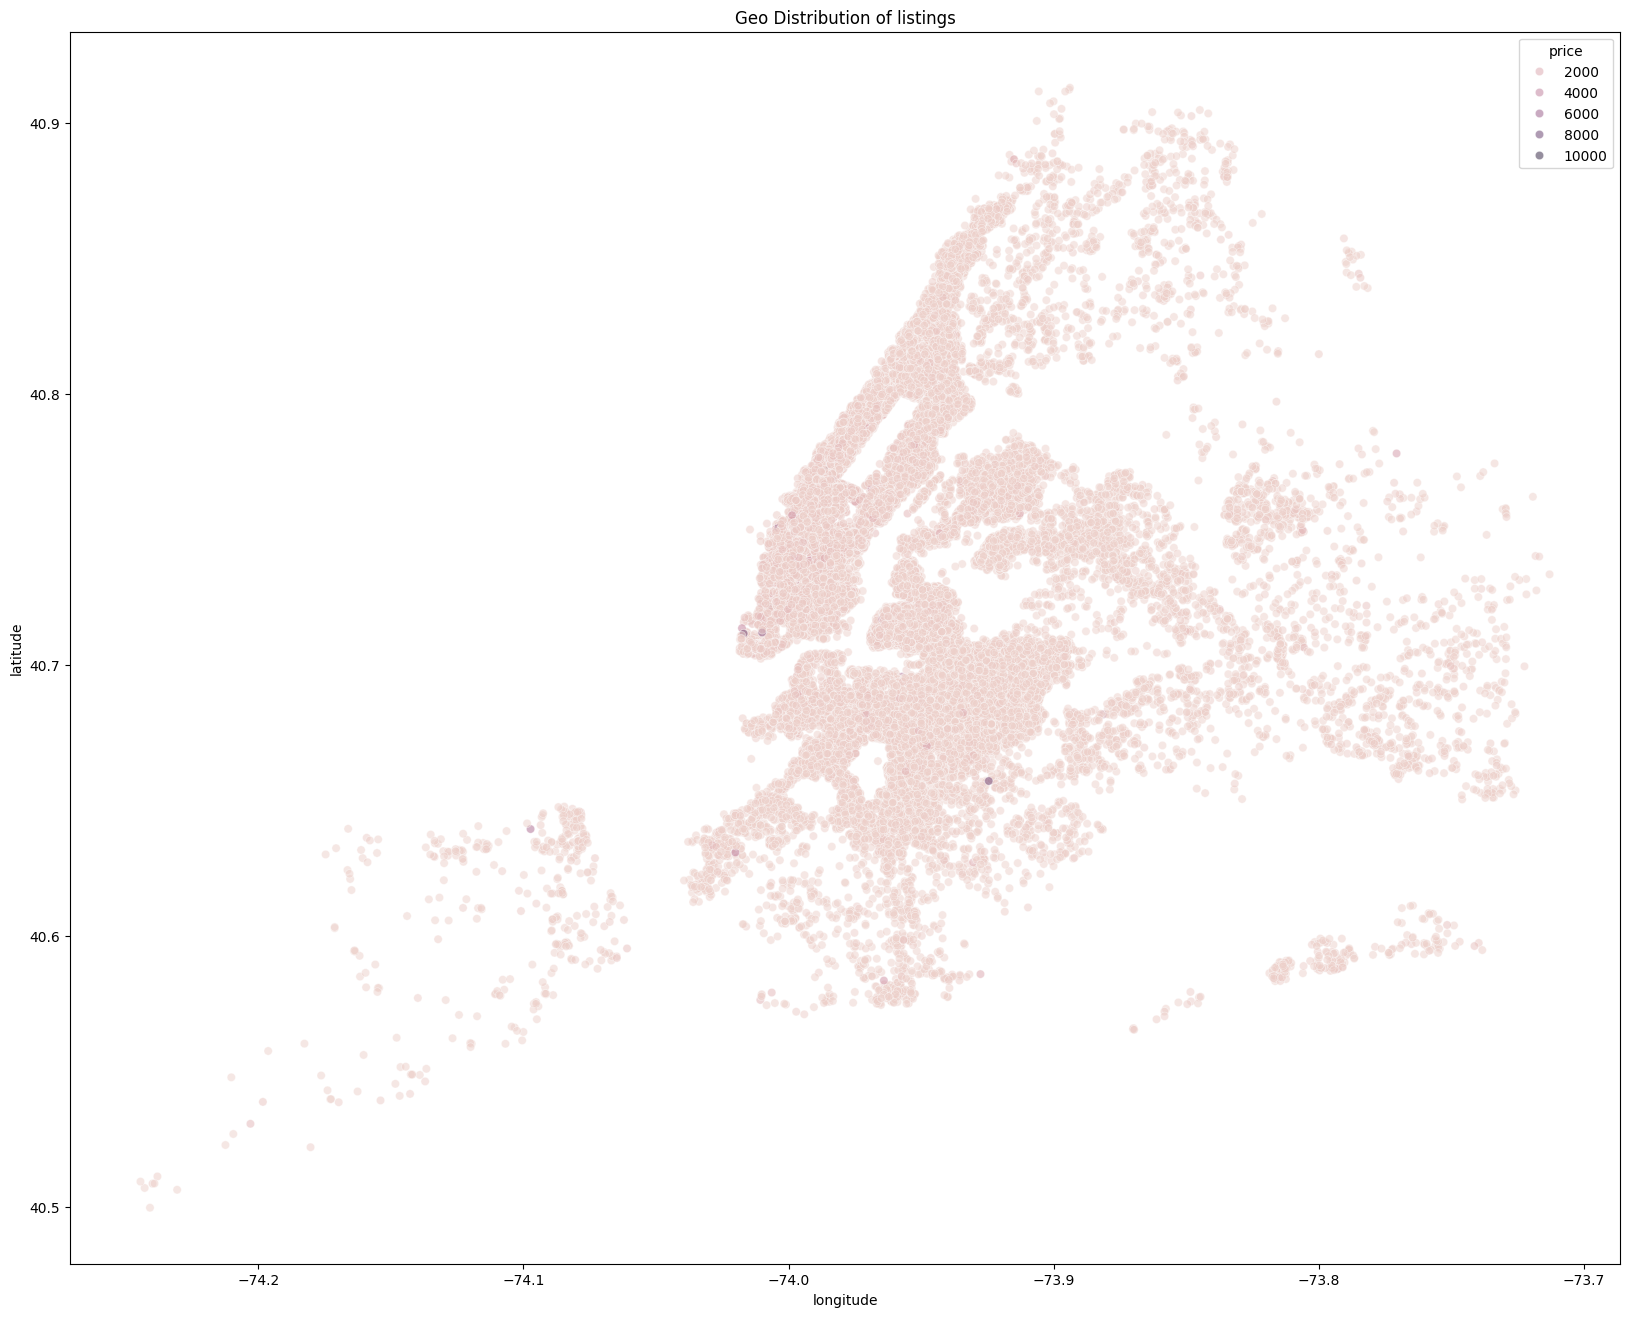

In [24]:
plt.figure(figsize=(20,16))
sns.scatterplot(x='longitude',y='latitude', hue='price', data=df, alpha=0.5)
plt.title('Geo Distribution of listings')
plt.show()

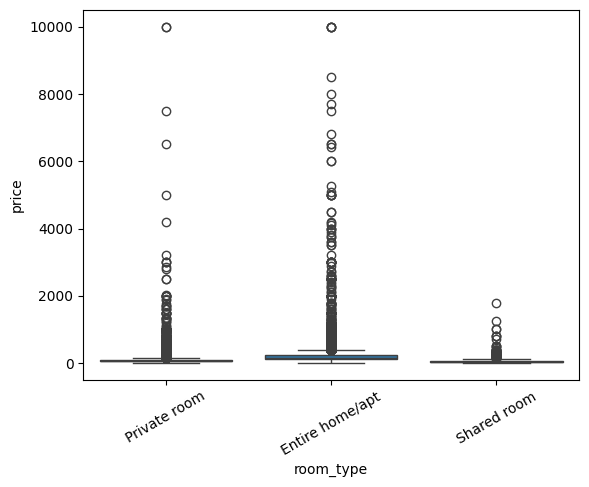

In [25]:
sns.boxplot(x='room_type', y='price', data=df)
plt.xticks(rotation=30)
plt.show()

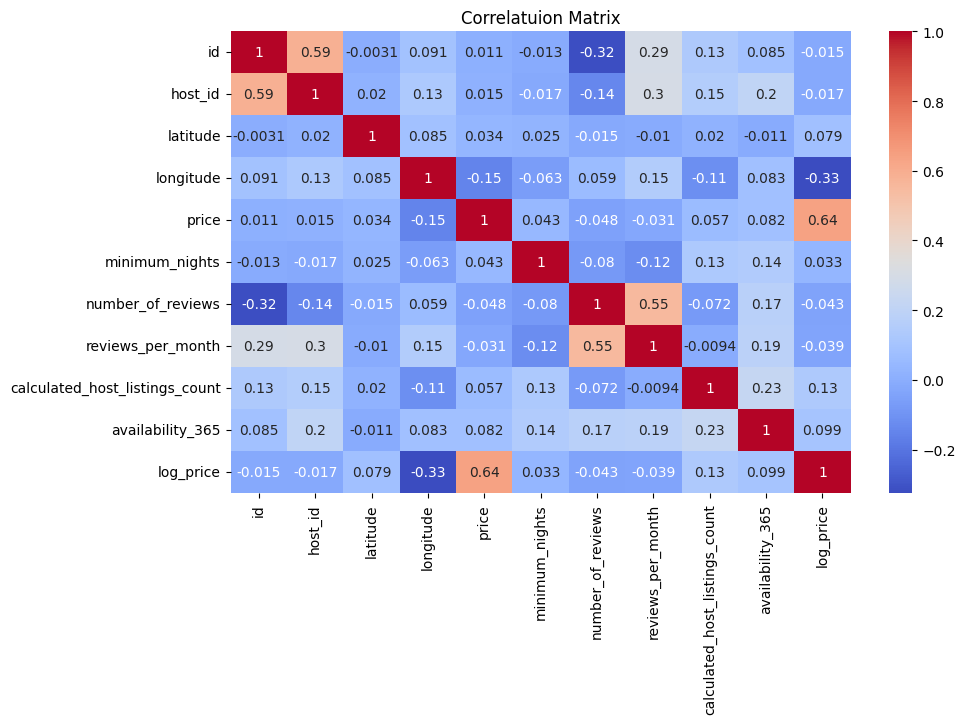

In [26]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlatuion Matrix')
plt.show()

In [27]:
df = df.drop(['id','name','host_name','last_review'],axis=1)

df['reviews_per_month'].fillna(0,inplace=True)

/tmp/ipykernel_6839/2684333359.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews_per_month'].fillna(0,inplace=True)


In [28]:
df['reviews_per_month'].skew()

np.float64(3.3016014291931928)

In [29]:
df['reviews_per_month_log'] = np.log1p(df['reviews_per_month'])

In [30]:
df['reviews_per_month_log'].skew()

np.float64(0.9505246674251294)

In [31]:
df.head()

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,log_price,reviews_per_month_log
0,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,5.010635,0.190620
1,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,5.420535,0.322083
2,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,5.017280,0.000000
3,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,4.499810,1.729884
4,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,4.394449,0.095310


In [34]:
df['availability_365'].value_counts()

,count
availability_365,
0,17530
365,1295
364,491
1,408
89,361
...,...
195,26
183,24
196,24


In [32]:
df['availability_bucket'] = pd.cut(df['availability_365'], bins=[0,50,150,300,365], labels=['Low','Medium','High','Very-High'])

In [33]:
df.head()

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,log_price,reviews_per_month_log,availability_bucket
0,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,5.010635,0.190620,Very-High
1,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,5.420535,0.322083,Very-High
2,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,5.017280,0.000000,Very-High
3,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,4.499810,1.729884,High
4,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,4.394449,0.095310,NaN


In [35]:
df['is_manhatten'] = (df['neighbourhood_group'] == 'Manhatten').astype(int)

In [36]:
df.head()

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,log_price,reviews_per_month_log,availability_bucket,is_manhatten
0,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,5.010635,0.190620,Very-High,0
1,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,5.420535,0.322083,Very-High,0
2,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,5.017280,0.000000,Very-High,0
3,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,4.499810,1.729884,High,0
4,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,4.394449,0.095310,NaN,0


In [37]:
df['price_per_reviews'] = df['price'] / (df['number_of_reviews'] + 1)

In [38]:
df.head()

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,log_price,reviews_per_month_log,availability_bucket,is_manhatten,price_per_reviews
0,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,5.010635,0.190620,Very-High,0,14.900000
1,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,5.420535,0.322083,Very-High,0,4.891304
2,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,5.017280,0.000000,Very-High,0,150.000000
3,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,4.499810,1.729884,High,0,0.328413
4,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,4.394449,0.095310,NaN,0,8.000000


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

X = df.drop(['price','log_price'],axis=1)
y = df['log_price']


cat_cols = X.select_dtypes(include = ['object','category']).columns
num_cols = X.select_dtypes(include=['float64','int64']).columns

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['host_id', 'latitude', 'longitude', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365',
       'reviews_per_month_log', 'is_manhatten', 'price_per_reviews'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['neighbourhood_group', 'neighbourhood', 'room_type',
       'availability_bucket'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [45]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('RMSE:', rmse)
print('R2:', r2)

RMSE: 0.6076691179413961
R2: 0.23107933054834429


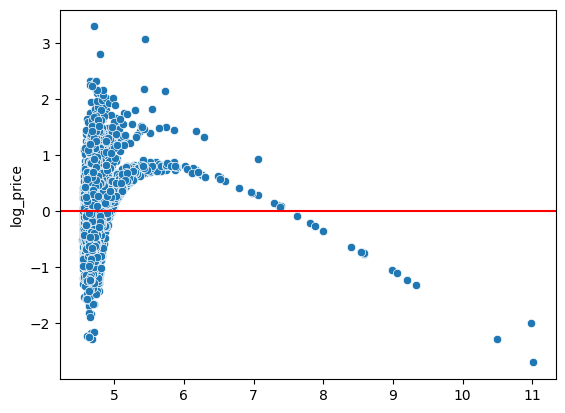

In [46]:
residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')
plt.show()

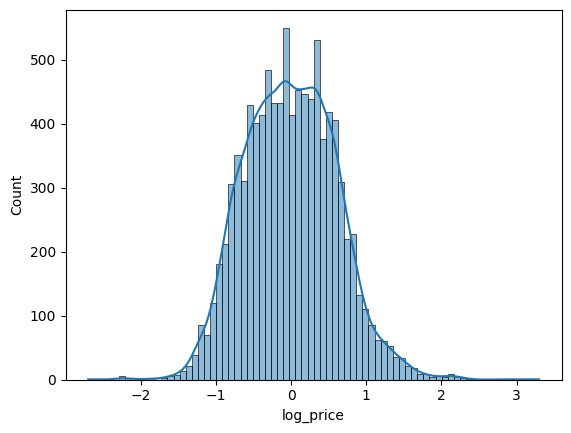

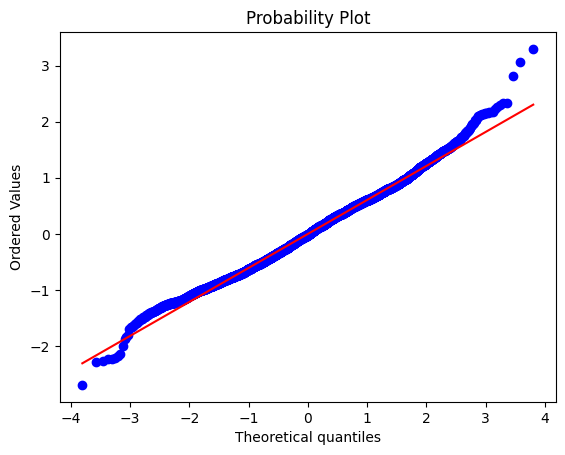

In [48]:
import scipy.stats as stats

sns.histplot(residuals, kde=True)
plt.show()

stats.probplot(residuals, dist="norm", plot=plt)
plt.show()